# Original vs Projected Pairwise Distances (Two Data Fields)

This notebook compares pairwise Euclidean distances in:
- original 2-field space
- projected space

It follows helper logic from `gaussian_random_projection_search.py` (loader + distance + Gaussian random projection style).

In [ ]:
from pathlib import Path
from itertools import combinations

try:
    import torch
except ImportError:
    torch = None

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize

from sklearn.random_projection import (
    johnson_lindenstrauss_min_dim,
    SparseRandomProjection,
    GaussianRandomProjection,
)

from random_projection import load_raw_binary, euclidean_distance, gaussian_random_projection_fp16_cpu, gaussian_random_projection_fp16_gpu

sns.set_theme(style="whitegrid")

data_dir = "/home/jwang96/datasets/Hurricane_new/clean-data-Jinyang/"
field_name = ["CLOUD", "P", "PRECIP", "QCLOUD", "QGRAUP", "QICE", "QRAIN", "QSNOW", "QVAPOR", "TC", "U", "V", "W"]
data_shape = (500, 500, 100)

projection_method = "manual_cuda"  # choices: ["manual_cpu", "manual_cuda", "sklearn_sparse", "sklearn_gaussian"]

In [14]:
def random_project(data_matrix, n_components, method="manual_cuda"):
    if method == "manual_cuda":
        if torch is None or not torch.cuda.is_available():
            print("CUDA backend unavailable; falling back to manual CPU projection")
            projected_matrix = gaussian_random_projection_fp16_cpu(
                data_matrix,
                n_components=n_components,
                random_state=42,
                feature_block_size=50_000,
            )
            print("Projection backend: manual_cpu")
        else:
            projected_matrix = gaussian_random_projection_fp16_gpu(
                data_matrix,
                n_components=n_components,
                random_state=42,
                feature_block_size=50_000,
            )
            print("Projection backend: manual_cuda")
    elif method == "manual_cpu":
        projected_matrix = gaussian_random_projection_fp16_cpu(
            data_matrix,
            n_components=n_components,
            random_state=42,
            feature_block_size=50_000,
        )
        print("Projection backend: manual_cpu")
    elif method == "sklearn_sparse":
        transformer = SparseRandomProjection(n_components=n_components, random_state=42)
        projected_matrix = transformer.fit_transform(data_matrix).astype(np.float32)
        print("Projection backend: sklearn_sparse")
    elif method == "sklearn_gaussian":
        transformer = GaussianRandomProjection(n_components=n_components, random_state=42)
        projected_matrix = transformer.fit_transform(data_matrix).astype(np.float32)
        print("Projection backend: sklearn_gaussian")
    else:
        raise ValueError(
            f"Unknown projection_method='{method}'. "
            "Choose from: manual_cpu, manual_cuda, sklearn_sparse, sklearn_gaussian"
        )
    return projected_matrix

### 2) Load data and compute pair-wise distance

In [28]:
timestep = 24

field_vectors = {}
for field in field_name:
    input_file = f"{data_dir}/{field}/{field}f{timestep:02d}.bin"
    raw = load_raw_binary(input_file, dtype=np.float32, shape=data_shape)
    field_vectors[field] = raw.reshape(-1)
    field_vectors[field] = (field_vectors[field] - field_vectors[field].mean()) / (field_vectors[field].std() + 1e-8)

print(f"Loaded timestep f{timestep:02d} for {len(field_vectors)} fields")

n_samples = len(field_name)
eps = 0.1
min_components = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=eps)
print(f"Minimum number of components for Random Projection: {min_components}")

# performing Random Projection using the selected method
data_matrix = np.stack([field_vectors[field] for field in field_name], axis=0)

projected_matrix = random_project(data_matrix, n_components=min_components, method=projection_method)

projected_vectors = {
    field: projected_matrix[idx]
    for idx, field in enumerate(field_name)
}

# Build original and projected pair-wise distance matrices
for i, field_i in enumerate(field_name):
    for j, field_j in enumerate(field_name):
        dist_orig = euclidean_distance(field_vectors[field_i], field_vectors[field_j])

distance_original = np.zeros((n_samples, n_samples), dtype=np.float32)
distance_projected = np.zeros((n_samples, n_samples), dtype=np.float32)
for i, field_i in enumerate(field_name):
    for j, field_j in enumerate(field_name):
        dist_orig = euclidean_distance(field_vectors[field_i], field_vectors[field_j])
        distance_original[i, j] = dist_orig
        dist_proj = euclidean_distance(projected_vectors[field_i], projected_vectors[field_j])
        distance_projected[i, j] = dist_proj

# diag_epsilon = np.float32(1e-3)
# np.fill_diagonal(distance_original, diag_epsilon)
# np.fill_diagonal(distance_projected, diag_epsilon)

Loaded timestep f24 for 13 fields
Minimum number of components for Random Projection: 2198
gaussian_random_projection_fp16_gpu took 1.347648s
Projection backend: manual_cuda


### 3) Plot Original vs Projected Distances (Pairwise)

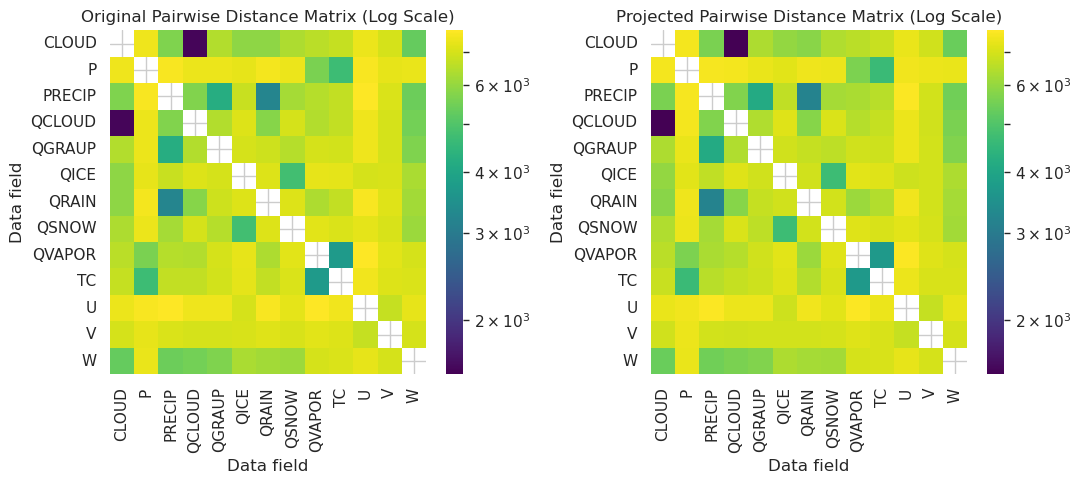

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

all_positive = np.concatenate([
    distance_original[distance_original > 0],
    distance_projected[distance_projected > 0],
])
if all_positive.size == 0:
    raise ValueError("All distances are zero; log scale requires positive values.")

vmin = all_positive.min()
vmax = all_positive.max()
norm = LogNorm(vmin=vmin, vmax=vmax)

sns.heatmap(distance_original, ax=axes[0], cmap='viridis', norm=norm)
axes[0].set_title('Original Pairwise Distance Matrix (Log Scale)')
axes[0].set_xlabel('Data field')
axes[0].set_ylabel('Data field')
axes[0].set_xticks(np.arange(n_samples) + 0.5)
axes[0].set_yticks(np.arange(n_samples) + 0.5)
axes[0].set_xticklabels(field_name, rotation=90, ha='center')
axes[0].set_yticklabels(field_name, rotation=0)

sns.heatmap(distance_projected, ax=axes[1], cmap='viridis', norm=norm)
axes[1].set_title('Projected Pairwise Distance Matrix (Log Scale)')
axes[1].set_xlabel('Data field')
axes[1].set_ylabel('Data field')
axes[1].set_xticks(np.arange(n_samples) + 0.5)
axes[1].set_yticks(np.arange(n_samples) + 0.5)
axes[1].set_xticklabels(field_name, rotation=90, ha='center')
axes[1].set_yticklabels(field_name, rotation=0)

plt.tight_layout()
plt.show()

### 4) Same-Field Pairwise Distances Across Time Steps (01-48)

This subsection compares pairwise Euclidean distances between time steps for a single field in original space vs projected space.

gaussian_random_projection_fp16_gpu took 1.247823s
Projection backend: manual_cuda
Loaded 10 time steps for field: CLOUD
Projection components (time-step analysis): 1973


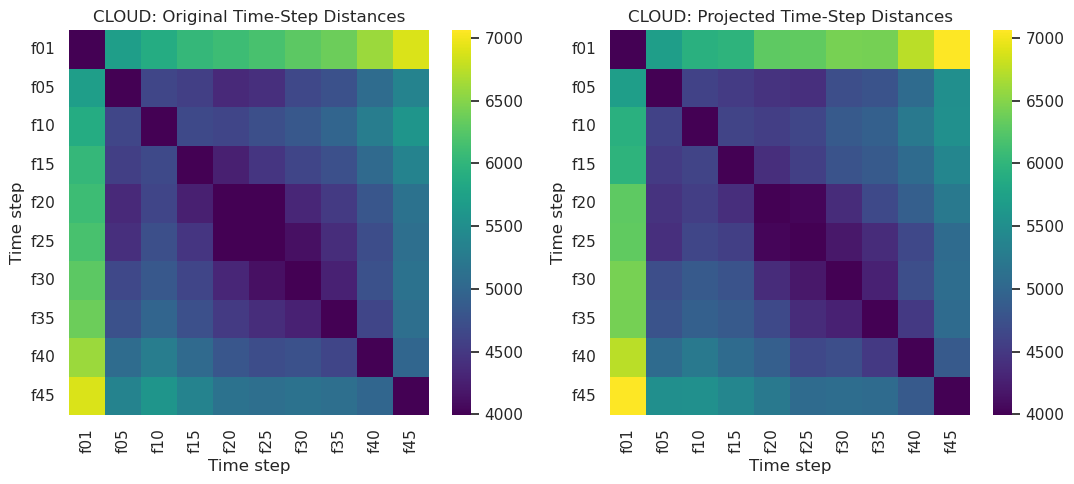

gaussian_random_projection_fp16_gpu took 1.101035s
Projection backend: manual_cuda
Loaded 10 time steps for field: P
Projection components (time-step analysis): 1973


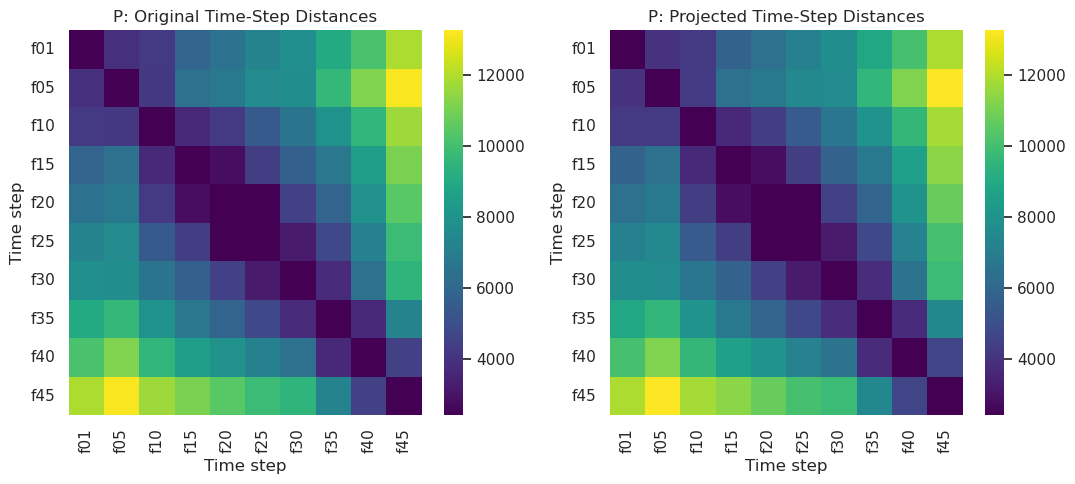

gaussian_random_projection_fp16_gpu took 1.578634s
Projection backend: manual_cuda
Loaded 10 time steps for field: PRECIP
Projection components (time-step analysis): 1973


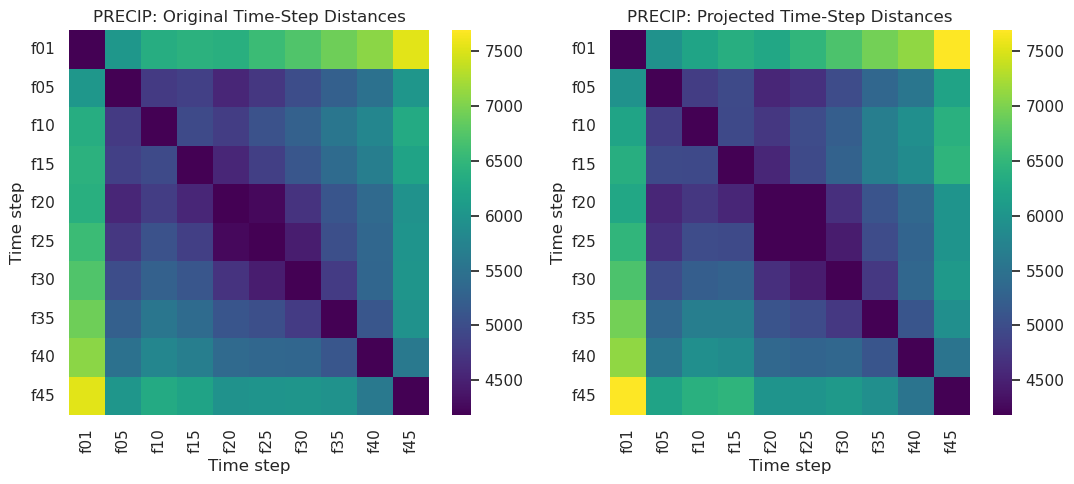

gaussian_random_projection_fp16_gpu took 1.896048s
Projection backend: manual_cuda
Loaded 10 time steps for field: QCLOUD
Projection components (time-step analysis): 1973


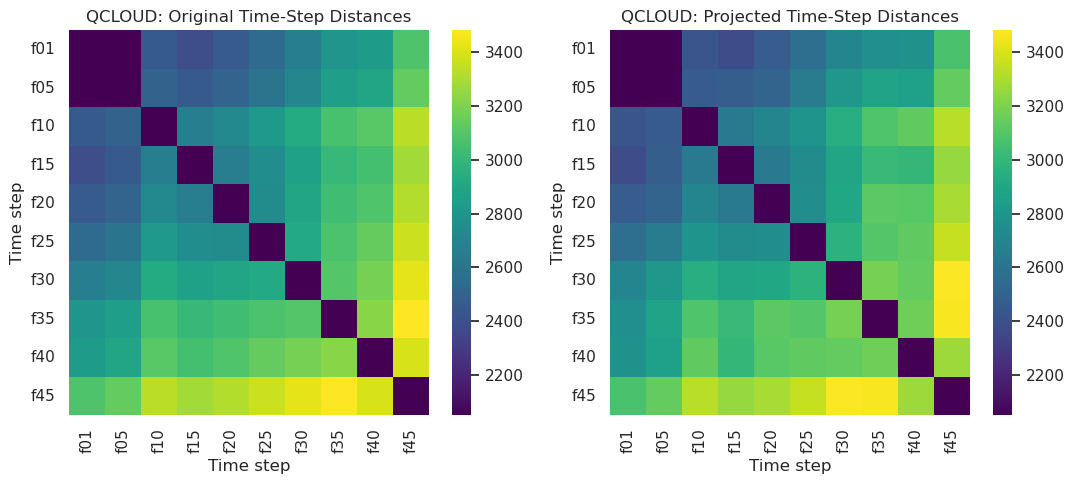

gaussian_random_projection_fp16_gpu took 2.878737s
Projection backend: manual_cuda
Loaded 10 time steps for field: QGRAUP
Projection components (time-step analysis): 1973


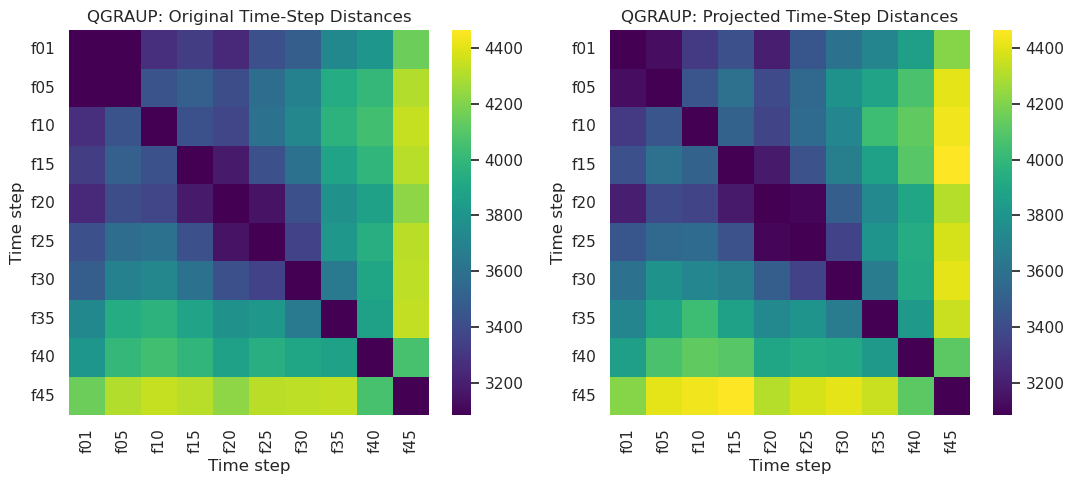

gaussian_random_projection_fp16_gpu took 1.466952s
Projection backend: manual_cuda
Loaded 10 time steps for field: QICE
Projection components (time-step analysis): 1973


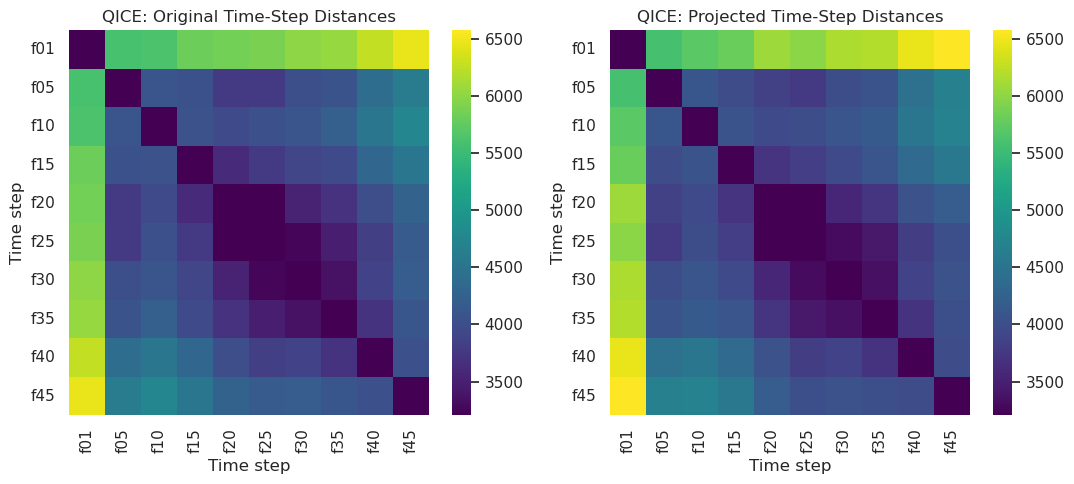

gaussian_random_projection_fp16_gpu took 3.587448s
Projection backend: manual_cuda
Loaded 10 time steps for field: QRAIN
Projection components (time-step analysis): 1973


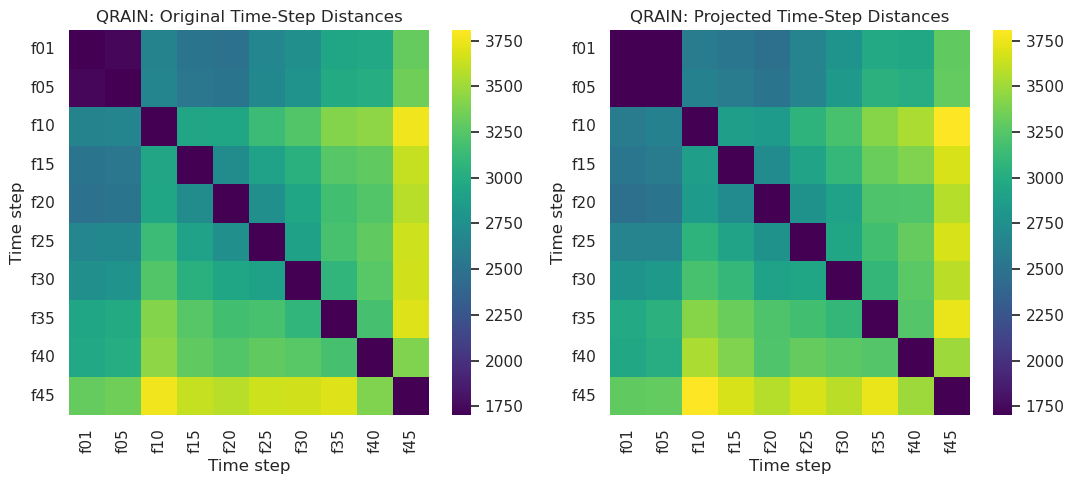

gaussian_random_projection_fp16_gpu took 2.043110s
Projection backend: manual_cuda
Loaded 10 time steps for field: QSNOW
Projection components (time-step analysis): 1973


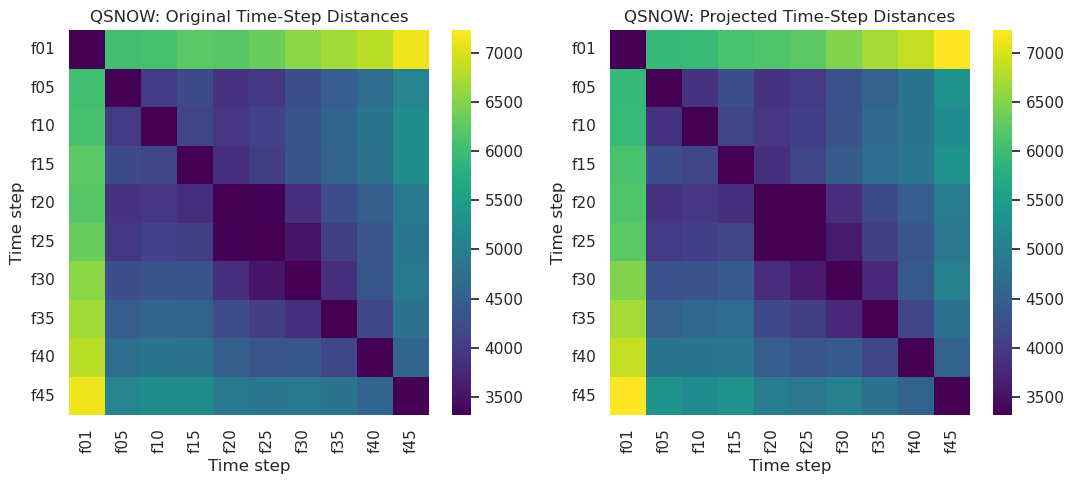

gaussian_random_projection_fp16_gpu took 1.095626s
Projection backend: manual_cuda
Loaded 10 time steps for field: QVAPOR
Projection components (time-step analysis): 1973


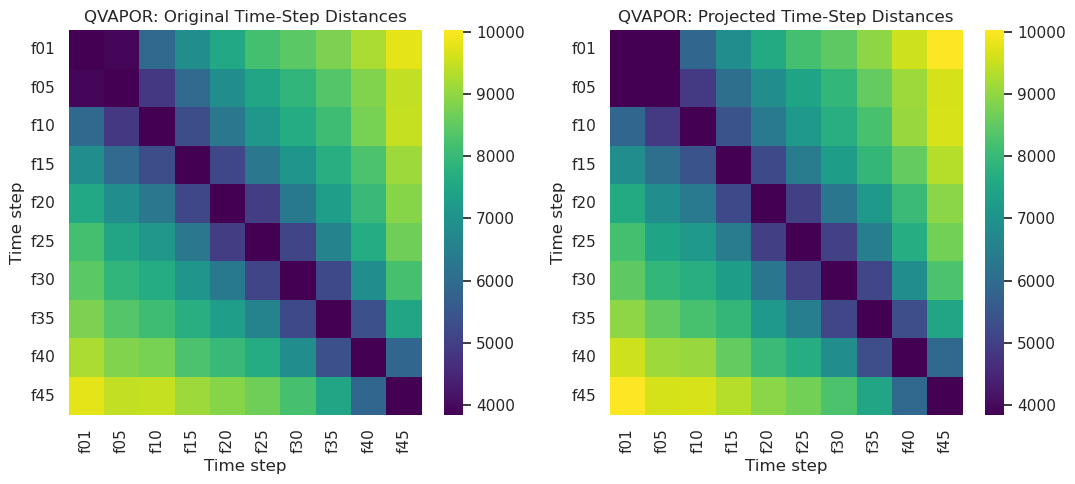

gaussian_random_projection_fp16_gpu took 1.101615s
Projection backend: manual_cuda
Loaded 10 time steps for field: TC
Projection components (time-step analysis): 1973


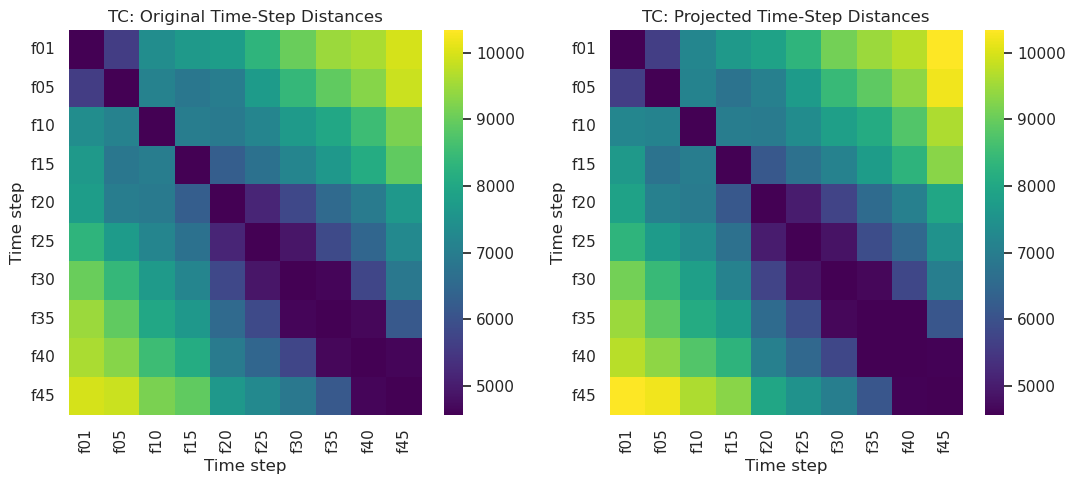

gaussian_random_projection_fp16_gpu took 1.120335s
Projection backend: manual_cuda
Loaded 10 time steps for field: U
Projection components (time-step analysis): 1973


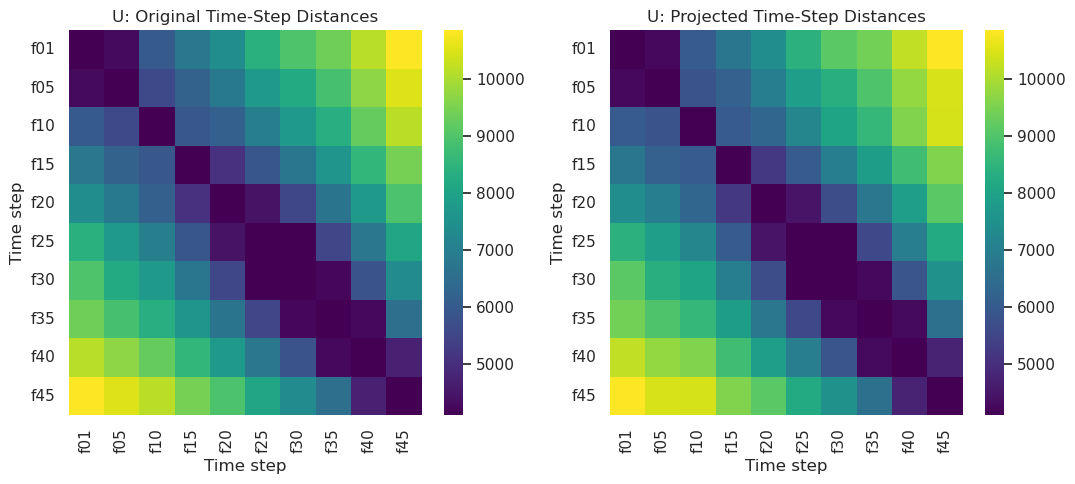

gaussian_random_projection_fp16_gpu took 1.106830s
Projection backend: manual_cuda
Loaded 10 time steps for field: V
Projection components (time-step analysis): 1973


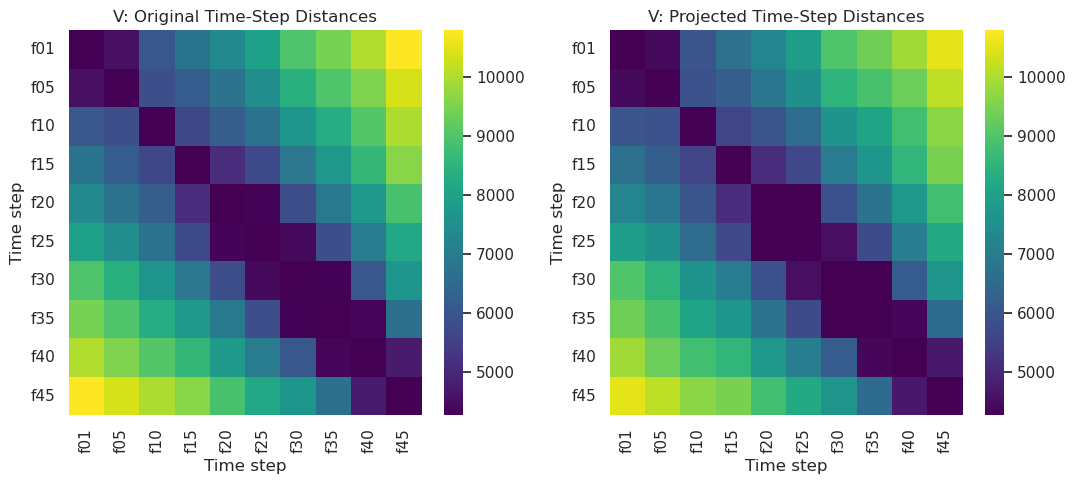

gaussian_random_projection_fp16_gpu took 1.080526s
Projection backend: manual_cuda
Loaded 10 time steps for field: W
Projection components (time-step analysis): 1973


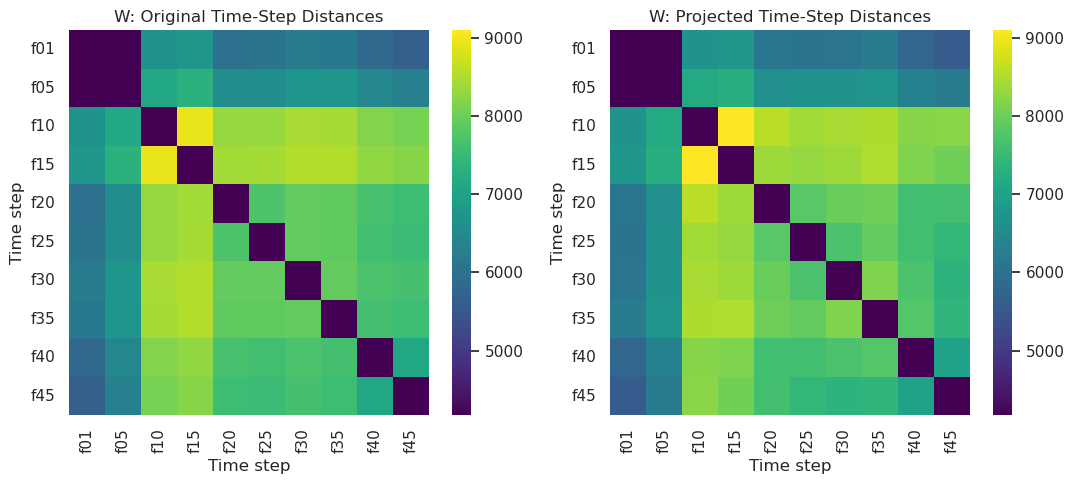

In [32]:
for field_for_time in field_name:
    # time_steps = list(range(1, 49))
    time_steps = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45]

    time_vectors = []
    for ts in time_steps:
        input_file = f"{data_dir}/{field_for_time}/{field_for_time}f{ts:02d}.bin"
        raw = load_raw_binary(input_file, dtype=np.float32, shape=data_shape)
        time_vectors.append(raw.reshape(-1))
    
    time_matrix = np.stack(time_vectors, axis=0)

    time_matrix = (time_matrix - time_matrix.mean(axis=0, keepdims=True)) / (time_matrix.std(axis=0, keepdims=True) + 1e-8)

    n_time_samples = time_matrix.shape[0]

    # JL-based component count for 48 samples
    eps_time = 0.1
    min_components_time = johnson_lindenstrauss_min_dim(n_samples=n_time_samples, eps=eps_time)

    time_projected_matrix = random_project(time_matrix, n_components=min_components_time, method=projection_method)

    distance_time_original = np.zeros((n_time_samples, n_time_samples), dtype=np.float32)
    distance_time_projected = np.zeros((n_time_samples, n_time_samples), dtype=np.float32)

    for i in range(n_time_samples):
        for j in range(n_time_samples):
            distance_time_original[i, j] = euclidean_distance(time_matrix[i], time_matrix[j])
            distance_time_projected[i, j] = euclidean_distance(time_projected_matrix[i], time_projected_matrix[j])

    # diag_epsilon_time = np.float32(1e-2)
    # np.fill_diagonal(distance_time_original, diag_epsilon_time)
    # np.fill_diagonal(distance_time_projected, diag_epsilon_time)

    print(f"Loaded {n_time_samples} time steps for field: {field_for_time}")
    print(f"Projection components (time-step analysis): {min_components_time}")

    ## plotting
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    all_positive_time = np.concatenate([
        distance_time_original[distance_time_original > 0],
        distance_time_projected[distance_time_projected > 0],
    ])
    if all_positive_time.size == 0:
        raise ValueError("All time-step distances are zero; log scale requires positive values.")

    vmin_time = all_positive_time.min()
    vmax_time = all_positive_time.max()
    norm_time = Normalize(vmin=vmin_time, vmax=vmax_time)

    tick_pos = np.arange(len(time_steps)) + 0.5
    tick_labels = [f"f{ts:02d}" if ts % 5 == 0 or ts in (1, 48) else "" for ts in time_steps]

    sns.heatmap(distance_time_original, ax=axes[0], cmap='viridis', norm=norm_time)
    axes[0].set_title(f'{field_for_time}: Original Time-Step Distances')
    axes[0].set_xlabel('Time step')
    axes[0].set_ylabel('Time step')
    axes[0].set_xticks(tick_pos)
    axes[0].set_yticks(tick_pos)
    axes[0].set_xticklabels(tick_labels, rotation=90)
    axes[0].set_yticklabels(tick_labels, rotation=0)

    sns.heatmap(distance_time_projected, ax=axes[1], cmap='viridis', norm=norm_time)
    axes[1].set_title(f'{field_for_time}: Projected Time-Step Distances')
    axes[1].set_xlabel('Time step')
    axes[1].set_ylabel('Time step')
    axes[1].set_xticks(tick_pos)
    axes[1].set_yticks(tick_pos)
    axes[1].set_xticklabels(tick_labels, rotation=90)
    axes[1].set_yticklabels(tick_labels, rotation=0)

    plt.tight_layout()
    plt.show()

In [ ]:
X.shape

(48, 25000000)